# **Predictive Analysis - U.S. Amazon Revenue Analytics**

- **Dataset**: [Open e-commerce 1.0: Five years of crowdsourced U.S. Amazon purchase histories with user demographics](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/YGLYDY)

- **Article**: [Link to the Article](https://www.nature.com/articles/s41597-024-03329-6)

---

## *Predicting Future High-Value Customers*

> ### **Business Problem**
    How can Amazon use historical purchase behaviour and selected customer characteristics to identify customers with high future revenue potential and allocate marketing resources more efficiently?

### **Objective**
Using customer purchase behaviour from 1 January 2018 to 31 December 2020, we predict whether a customer belongs to the top 25% of spenders during 1 January 2021 to 31 December 2022.

### **Unit of Analysis**
One row represents one customer, identified by `Survey ResponseID`.

### **Target Variable**
`Target_HighValue`:
- `1`: customer belongs to the top 25% of future spenders in 2021–2022.
- `0`: customer does not belong to the top 25%.

### **Leakage Prevention**
All predictors are built only from 2018–2020 information. Spending from 2021–2022 is used only to create the target variable.

---

## *Research Questions*

- Customers with higher historical purchase frequency and monetary value are more likely to become high-value customers in the future?
- Behavioural variables provide better predictive performance than demographic variables alone?
- Combining demographic and behavioral variables improves performance relative to either feature group alone?
- Tree-based models outperform logistic regression because customer value is influenced by nonlinear relationships and interactions?
- Customers in the highest predicted probability decile exhibit substantially higher high-value rates than randomly selected customers?

---

# **Data Integration**

#### **Initial Setup**
*   **Libraries**: Essential libraries such as `pandas`, `numpy`, `matplotlib.pyplot`, `sklearn.preprocessing.StandardScaler`, `seaborn` and `os` are imported.


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import os

RANDOM_STATE = 42

#### **Data Loading**
*   **Data Loading**: Raw purchase data (`amazon-purchases.csv`) and survey data (`survey.csv`) are loaded into separate pandas DataFrames after mounting Google Drive.

In [ ]:
# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# The datasets need to be placed in a directory called 'Business Analytics' on Google Drive. Arrange it according your files location on Google Drive

drive_directory = '/content/drive/MyDrive/Business Analytics'

amzn_purchases_csv = os.path.join(drive_directory, 'amazon-purchases.csv')
survey_csv = os.path.join(drive_directory, 'survey.csv')

# Load both datasets from the Google Drive directory.
amzn_data = pd.read_csv(amzn_purchases_csv)
survey_data = pd.read_csv(survey_csv)

---

# **Data Cleaning and Preprocessing**

In [ ]:
# Merge Data
data = pd.merge(amzn_data, survey_data, left_on='Survey ResponseID', right_on='Survey ResponseID')

In [ ]:
# List of columns to be removed
rm_cols = [
    'Q-substance-use-cigarettes',
    'Q-substance-use-marijuana',
    'Q-substance-use-alcohol',
    'Q-personal-diabetes',
    'Q-demos-race',
    'Q-amazon-use-howmany',
    'Q-amazon-use-hh-size',
    'Q-personal-wheelchair',
    'Q-life-changes',
    'Q-sell-YOUR-data',
    'Q-sell-consumer-data',
    'Q-small-biz-use',
    'Q-census-use',
    'Q-research-society',
    'Q-sexual-orientation',
    'Q-demos-hispanic'
]

# Drop the specified columns
data = data.drop(columns=rm_cols, errors='ignore')

In [ ]:
# Type Casting and Data Cleaning and Missing Values

# Convert 'Order Date' to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')
# Convert 'Purchase Price Per Unit' and 'Quantity' to numeric
data['Purchase Price Per Unit'] = pd.to_numeric(data['Purchase Price Per Unit'], errors='coerce')
data['Quantity'] = pd.to_numeric(data['Quantity'], errors='coerce')


# Hanlding missing values

print("Missing values per column before cleaning:")
print(data.isnull().sum())

print("Where critical predictive data is missing per column before cleaning:")
print(data[['Order Date', 'Purchase Price Per Unit', 'Quantity']].isnull().sum())

initial_shape = data.shape
data = data.dropna(subset=['Order Date', 'Purchase Price Per Unit', 'Quantity'])

# Fill categorical survey missing values with 'Unknown'
cat_cols = data.select_dtypes(include=['object']).columns
data[cat_cols] = data[cat_cols].fillna('Unknown')

print(f"\nRows removed: {initial_shape[0] - data.shape[0]}")
print(f"\nData shape after handling missing values: {data.shape}")


Missing values per column before cleaning:
Order Date                      0
Purchase Price Per Unit         0
Quantity                        0
Shipping Address State      87812
Title                       89740
ASIN/ISBN (Product Code)      973
Category                    89458
Survey ResponseID               0
Q-demos-age                     0
Q-demos-education               0
Q-demos-income                  0
Q-demos-gender                  0
Q-demos-state                   0
Q-amazon-use-how-oft            0
dtype: int64
Where critical predictive data is missing per column before cleaning:
Order Date                 0
Purchase Price Per Unit    0
Quantity                   0
dtype: int64

Rows removed: 0

Data shape after handling missing values: (1850717, 14)



*   **Data Merging**: `amzn_data` and `survey_data` were merged on `Survey ResponseID` to consolidate all customer information.
*   **Column Removal**: Irrelevant columns were dropped from the merged DataFrame, ensuring only pertinent data was retained.
*   **Type Casting**: `Order Date` was converted to datetime objects, and `Purchase Price Per Unit` and `Quantity` to numeric types, handling errors gracefully.
*   **Missing Value Handling**: Rows with missing `Purchase Price Per Unit`, `Quantity` or `Order Date` were dropped. Categorical missing values were imputed with 'Unknown'.

---

# **Feature Engineering & Leakage Control**
To predict *future* revenue, we must split the data into a **Feature Window** and a **Target Window**. Using data from the target window to create features would cause data leakage.

#### **Prediction Design and Leakage Control**

To make the analysis genuinely predictive, the data are separated into two non-overlapping periods:

| Period | Dates | Purpose |
|---|---|---|
| Historical feature window | 1 January 2018 – 31 December 2020 | Create predictor variables |
| Future outcome window | 1 January 2021 – 31 December 2022 | Create the high-value target |

*No information from the future outcome window is used as a predictor.*

In [ ]:

# Define the feature and outcome window dates

feature_window_start = pd.to_datetime('2018-01-01')
feature_window_end = pd.to_datetime('2020-12-31')
outcome_window_start = pd.to_datetime('2021-01-01')
outcome_window_end = pd.to_datetime('2022-12-31')

print(f"Feature Window: {feature_window_start} to {feature_window_end}")
print(f"Outcome Window: {outcome_window_start} to {outcome_window_end}")

# Split data based on defined windows
historical_data = data[(data['Order Date'] >= feature_window_start) & (data['Order Date'] <= feature_window_end)].copy()
future_data = data[(data['Order Date'] >= outcome_window_start) & (data['Order Date'] <= outcome_window_end)].copy()

print(f"Shape of historical_data: {historical_data.shape}")
print(f"Shape of future_data: {future_data.shape}")

# Order Value Calculation: `Order_Value` (`Purchase Price Per Unit * Quantity`) calculated for each transaction in `historical_data`.
historical_data['Order_Value'] = historical_data['Purchase Price Per Unit'] * historical_data['Quantity']
print("First 5 rows of historical_data with 'Order_Value':")
display(historical_data.head())

Feature Window: 2018-01-01 00:00:00 to 2020-12-31 00:00:00
Outcome Window: 2021-01-01 00:00:00 to 2022-12-31 00:00:00
Shape of historical_data: (900693, 14)
Shape of future_data: (910100, 14)
First 5 rows of historical_data with 'Order_Value':


,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,Q-demos-age,Q-demos-education,Q-demos-income,Q-demos-gender,Q-demos-state,Q-amazon-use-how-oft,Order_Value
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF,35 - 44 years,Bachelor's degree,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,7.98
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF,35 - 44 years,Bachelor's degree,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,13.99
2,2018-12-24,8.99,1.0,NJ,Unknown,B078JZTFN3,Unknown,R_01vNIayewjIIKMF,35 - 44 years,Bachelor's degree,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,8.99
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF,35 - 44 years,Bachelor's degree,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,10.45
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF,35 - 44 years,Bachelor's degree,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,10.00


---

## **Feature Extraction**

#### **Extract RFM Features**

In [ ]:
rfm_features = historical_data.groupby('Survey ResponseID').agg(
    Recency=('Order Date', lambda x: (feature_window_end - x.max()).days),
    Frequency=('Order Date', 'count'),
    Monetary=('Order_Value', 'sum')
)

print("First 5 rows of RFM features:")
display(rfm_features.head())

First 5 rows of RFM features:


,Recency,Frequency,Monetary
Survey ResponseID,,,
R_01vNIayewjIIKMF,125,89,1933.84
R_037XK72IZBJyF69,0,457,7097.24
R_038ZU6kfQ5f89fH,13,30,1632.83
R_03aEbghUILs9NxD,308,55,1028.37
R_06RZP9pS7kONINr,2,197,4819.42


### **Additional Behavioral Features**


The raw purchase file is at the transaction level. To prepare for modeling, we aggregate historical purchases (2018–2020) into one row per customer, creating a rich set of behavioral indicators.

| Feature Group | Feature Name | Definition | Interpretation |
|:---|:---|:---|:---|
| **RFM** | Recency | Days since latest purchase as of 31 Dec 2020 | Lower = More recent activity |
| **RFM** | Frequency | Total number of purchase records | Higher = More frequent engagement |
| **RFM** | Monetary | Total historical spending ($) | Higher = Greater historical value |
| **Value Distribution** | Avg/Med/Max Purchase Value | Mean, median, and max transaction amounts | Captures typical vs. extreme spending |
| **Activity** | Active Purchase Months/Days | Count of unique months/days with a purchase | Captures sustained vs. sporadic loyalty |
| **Breadth** | Category Diversity | Number of distinct product categories purchased | Captures breadth of interest |
| **Tenure** | Customer Tenure | Days from first purchase to 31 Dec 2020 | Captures relationship duration |
| **Consistency** | Purchase Regularity | Std. deviation of days between purchases | Captures habit stability |
| **Efficiency Ratios** | Avg Quantity / Purchase | Total Quantity / Frequency | Captures bulk-buying behavior |
| **Efficiency Ratios** | Purchases Per Month | Frequency / Active Months | Identifies high-velocity shoppers |

In [ ]:
# Create one row per customer using historical purchases only
hist_features = historical_data.groupby('Survey ResponseID').agg(
    # RFM features
    Recency=('Order Date', lambda x: (feature_window_end - x.max()).days),
    Frequency=('Order Date', 'count'),
    Monetary=('Order_Value', 'sum'),

    # Purchase value behaviour
    Avg_Purchase_Value=('Order_Value', 'mean'),
    Median_Purchase_Value=('Order_Value', 'median'),
    Max_Purchase_Value=('Order_Value', 'max'),

    # Quantity and activity features
    Total_Quantity=('Quantity', 'sum'),
    Active_Purchase_Months=('Order Date', lambda x: x.dt.to_period('M').nunique()),
    Active_Purchase_Days=('Order Date', 'nunique'),

    # Product breadth
    Category_Diversity=('Category', 'nunique'),

    # Relationship duration
    Customer_Tenure=('Order Date', lambda x: (feature_window_end - x.min()).days),

    # Consistency of gaps between purchases
    Purchase_Regularity=('Order Date', lambda x: x.sort_values().diff().dt.days.std())
).reset_index()

# Create useful ratio features
hist_features['Avg_Quantity_Per_Purchase'] = hist_features['Total_Quantity'] / hist_features['Frequency']
hist_features['Purchases_Per_Active_Month'] = hist_features['Frequency'] / hist_features['Active_Purchase_Months'].replace(0, np.nan)

print("Customer-level historical feature table shape:", hist_features.shape)
display(hist_features.head())
display(hist_features.describe().T)

Customer-level historical feature table shape: (4882, 15)


,Survey ResponseID,Recency,Frequency,Monetary,Avg_Purchase_Value,Median_Purchase_Value,Max_Purchase_Value,Total_Quantity,Active_Purchase_Months,Active_Purchase_Days,Category_Diversity,Customer_Tenure,Purchase_Regularity,Avg_Quantity_Per_Purchase,Purchases_Per_Active_Month
0,R_01vNIayewjIIKMF,125,89,1933.84,21.728539,14.33,150.00,93.0,20,53,40,758,10.853103,1.044944,4.450000
1,R_037XK72IZBJyF69,0,457,7097.24,15.530066,11.97,210.55,493.0,34,134,212,1078,6.319961,1.078775,13.441176
2,R_038ZU6kfQ5f89fH,13,30,1632.83,54.427667,29.99,399.98,33.0,11,14,18,744,46.414575,1.100000,2.727273
3,R_03aEbghUILs9NxD,308,55,1028.37,18.697636,11.73,99.99,55.0,12,29,39,1083,38.296833,1.000000,4.583333
4,R_06RZP9pS7kONINr,2,197,4819.42,24.464061,16.59,305.00,213.0,32,70,101,1073,11.086779,1.081218,6.156250


,count,mean,std,min,25%,50%,75%,max
Recency,4882.0,46.788202,124.016301,0.00,2.000000,9.000000,24.000000,1095.000000
Frequency,4882.0,184.492626,224.618126,1.00,39.000000,110.000000,245.000000,2298.000000
Monetary,4882.0,4358.614244,5179.882037,3.93,937.422500,2638.260000,5794.762500,60848.980000
Avg_Purchase_Value,4882.0,26.096510,15.161019,1.44,17.965766,23.122560,29.730317,290.270000
Median_Purchase_Value,4882.0,16.220195,10.129032,0.50,12.850000,14.990000,17.990000,330.990000
Max_Purchase_Value,4882.0,310.038068,350.773945,2.99,100.000000,199.990000,384.990000,6398.950000
Total_Quantity,4882.0,200.776116,250.811446,1.00,40.000000,117.000000,264.750000,2606.000000
Active_Purchase_Months,4882.0,22.051413,11.258688,1.00,12.000000,23.000000,33.000000,36.000000
Active_Purchase_Days,4882.0,83.963744,88.987708,1.00,20.000000,54.000000,118.000000,695.000000
Category_Diversity,4882.0,78.782466,70.726865,1.00,24.250000,60.000000,113.000000,525.000000



*   **RFM Features**: Recency, Frequency, and Monetary values were computed from `historical_data` for each `Survey ResponseID`.
*   **Additional Behavioral Features**:
    *   **Value Distribution**: `Avg_Purchase_Value`, `Median_Purchase_Value`, `Max_Purchase_Value`.
    *   **Activity Metrics**: `Total_Quantity`, `Active_Purchase_Months`, `Active_Purchase_Days`.
    *   **Loyalty & Consistency**: `Customer_Tenure`, `Purchase_Regularity` (standard deviation of days between orders).
    *   **Product Breadth**: `Category_Diversity` (number of unique categories).
    *   **Efficiency Ratios**: `Avg_Quantity_Per_Purchase` and `Purchases_Per_Active_Month`.

---

## **Target Variable and Integration of Demographic Features**

#### **Future High-Value Customer**

Future customer value is calculated using total spending in the outcome period from 1 January 2021 to 31 December 2022.

Customers whose future spending is at or above the 75th percentile are labelled as high value.

>  \
  Target\_HighValue =
    \begin{cases}
    1, & \text{if future spending is in the top 25%} \\
    0, & \text{otherwise}
    \end{cases}


*Customers with no purchases in the future period receive future spending equal to zero.*

In [ ]:
# 1. Calculate future revenue
future_data['Order_Value'] = future_data['Purchase Price Per Unit'] * future_data['Quantity']
future_revenue = future_data.groupby('Survey ResponseID')['Order_Value'].sum()

# 2. Match future spending to historical features
hist_features['Future_Spending'] = hist_features['Survey ResponseID'].map(future_revenue).fillna(0)

# 3. Calculate 75th percentile threshold
high_value_threshold = hist_features['Future_Spending'].quantile(0.75)

# 4. Create binary classification target
hist_features['Target_HighValue'] = (hist_features['Future_Spending'] >= high_value_threshold).astype(int)

print(f"High-value threshold (75th percentile): ${high_value_threshold:,.2f}")

target_summary = pd.DataFrame({
    'Customer Count': hist_features['Target_HighValue'].value_counts(),
    'Percentage': hist_features['Target_HighValue'].value_counts(normalize=True).mul(100).round(2)
})
target_summary.index = ['Not High Value (0)', 'High Value (1)']
display(target_summary)

High-value threshold (75th percentile): $5,908.16


,Customer Count,Percentage
Not High Value (0),3661,74.99
High Value (1),1221,25.01


#### **Customer Characteristics and Ethical Feature Selection**

 *Selected customer characteristics are added to the behavioural feature table:*
  >  - Age group
  >  - Income group
  >  - Gender
  >  - Education level
  >  - Survey-reported U.S. state
  >  - Amazon-use frequency

Sensitive characteristics, including health, substance use, race, ethnicity, and sexual orientation, are not included in the model.

In [ ]:
# 5. Integrate Demographics
selected_demo_cols = ['Survey ResponseID', 'Q-demos-age', 'Q-demos-income', 'Q-demos-gender', 'Q-demos-education', 'Q-demos-state', 'Q-amazon-use-how-oft']
demographics = data[selected_demo_cols].drop_duplicates(subset='Survey ResponseID').copy()

final_df = hist_features.merge(demographics, on='Survey ResponseID', how='left')

# Label missing demographics as Unknown
demo_cols = [col for col in selected_demo_cols if col != 'Survey ResponseID']
final_df[demo_cols] = final_df[demo_cols].fillna('Unknown')

# 6. Validation
assert final_df.shape[0] == final_df['Survey ResponseID'].nunique(), "Error: Multiple rows per customer!"
print(f"\nSuccess: Final dataset shape {final_df.shape}. One row represents one customer.")
display(final_df.head())


Success: Final dataset shape (4882, 23). One row represents one customer.


,Survey ResponseID,Recency,Frequency,Monetary,Avg_Purchase_Value,Median_Purchase_Value,Max_Purchase_Value,Total_Quantity,Active_Purchase_Months,Active_Purchase_Days,...,Avg_Quantity_Per_Purchase,Purchases_Per_Active_Month,Future_Spending,Target_HighValue,Q-demos-age,Q-demos-income,Q-demos-gender,Q-demos-education,Q-demos-state,Q-amazon-use-how-oft
0,R_01vNIayewjIIKMF,125,89,1933.84,21.728539,14.33,150.00,93.0,20,53,...,1.044944,4.450000,2986.17,0,35 - 44 years,"$25,000 - $49,999",Male,Bachelor's degree,New Jersey,Less than 5 times per month
1,R_037XK72IZBJyF69,0,457,7097.24,15.530066,11.97,210.55,493.0,34,134,...,1.078775,13.441176,10492.65,1,55 - 64 years,"$25,000 - $49,999",Female,Bachelor's degree,Pennsylvania,Less than 5 times per month
2,R_038ZU6kfQ5f89fH,13,30,1632.83,54.427667,29.99,399.98,33.0,11,14,...,1.100000,2.727273,2614.71,0,25 - 34 years,"$25,000 - $49,999",Male,High school diploma or GED,California,Less than 5 times per month
3,R_03aEbghUILs9NxD,308,55,1028.37,18.697636,11.73,99.99,55.0,12,29,...,1.000000,4.583333,2765.28,0,35 - 44 years,"$50,000 - $74,999",Male,Bachelor's degree,Virginia,Less than 5 times per month
4,R_06RZP9pS7kONINr,2,197,4819.42,24.464061,16.59,305.00,213.0,32,70,...,1.081218,6.156250,6404.28,1,65 and older,"$75,000 - $99,999",Female,Bachelor's degree,South Dakota,More than 10 times per month


### **Target Integration Summary**
*   **Future Revenue Calculation**: Total revenue for each customer was calculated from `future_data` (2021-2022).
*   **High-Value Definition**: The `Target_HighValue` variable identifies customers in the **top 25% of spenders** (threshold identified in the summary table) to allow for a focused analysis of elite revenue drivers.
*   **Demographic Integration**: Survey data was merged and missing values were tagged as 'Unknown' to maintain row counts for behavioral analysis.



---



### **Feature Selection and Train-Test Split**

* *The target and future-spending variables are excluded from the input features.*

* An 80/20 stratified train-test split is used:
  - 80% of customers are used for training.
  - 20% are held back for final testing.
  - **Stratification** preserves the proportion of high-value customers (approx. 25%) in both sets.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Behavioral Features (Numeric)
numeric_features = [
    'Recency', 'Frequency', 'Monetary', 'Avg_Purchase_Value',
    'Median_Purchase_Value', 'Max_Purchase_Value', 'Total_Quantity',
    'Active_Purchase_Months', 'Active_Purchase_Days', 'Category_Diversity',
    'Customer_Tenure', 'Purchase_Regularity', 'Avg_Quantity_Per_Purchase',
    'Purchases_Per_Active_Month'
]

# 2. Demographic Features (Categorical)
categorical_features = [
    'Q-demos-age', 'Q-demos-income', 'Q-demos-gender',
    'Q-demos-education', 'Q-demos-state', 'Q-amazon-use-how-oft'
]

# 3. Define X and y
# Exclude IDs and Future_Spending to prevent leakage
X = final_df[numeric_features + categorical_features].copy()
y = final_df['Target_HighValue']
customer_ids = final_df['Survey ResponseID']

# 4. Perform 80/20 Stratified Split
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, customer_ids, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} customers")
print(f"Testing set: {X_test.shape[0]} customers")
print(f"High-Value Rate in Training: {y_train.mean():.2%}")

Training set: 3905 customers
Testing set: 977 customers
High-Value Rate in Training: 25.02%




---



### **Preprocessing Pipeline**

* *Numerical features are:*
  1. Imputed with the training-set median when missing.
  2. Standardised using `StandardScaler`.

* *Categorical features are:*
  1. Imputed with the most frequent training-set category when missing.
  2. Converted to binary indicator columns using **one-hot encoding**.

Preprocessing occurs inside a pipeline so that all transformations are learned from training data only. This prevents **preprocessing leakage**.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric Transformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Transformer
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

# Combined Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("Preprocessing Pipeline defined.")

Preprocessing Pipeline defined.


---

## **Model Training and Evaluation**

Each model is trained using the same training customers.

> #### *Training Logistic Regression, Decision Tree, Random Forest and Gradient Boosting Models*

We compare a baseline classifier and four predictive models.

| Model | Role in the project |
|---|---|
| Dummy Classifier | Minimal benchmark |
| Logistic Regression | Transparent linear baseline |
| Decision Tree | Interpretable nonlinear model |
| Random Forest | Ensemble model capturing nonlinear relationships and interactions |
| Gradient Boosting | Sequential ensemble model that improves earlier errors |

All models use the same training and test customers, so their scores are directly comparable.



#### **Evaluation Measures**

- **Accuracy:** overall correctness.
- **Precision:** reliability of customers predicted as high value.
- **Recall:** ability to identify actual future high-value customers.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** ability to rank future high-value customers above non-high-value customers across different campaign thresholds.

Accuracy alone is not sufficient because the high-value class is smaller and commercially more important.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

# Define the model suite
models = {
    'Dummy Baseline': DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, min_samples_leaf=10),
    'Random Forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42)
}

# Create pipelines for each model
pipelines = {
    name: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    for name, model in models.items()
}

# Store results
fitted_pipelines = {}
test_predictions = {}
test_probabilities = {}
results = []

for name, pipeline in pipelines.items():
    print(f"Training {name}...")

    # Fit and Predict
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Store objects
    fitted_pipelines[name] = pipeline
    test_predictions[name] = y_pred
    test_probabilities[name] = y_prob

    # Calculate and store metrics for each specific model in the loop
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

# Create the final comparison dataframe
results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
display(results_df.style.format({'Accuracy': '{:.3f}', 'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1-score': '{:.3f}', 'ROC-AUC': '{:.3f}'}))

Training Dummy Baseline...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosting,0.879,0.781,0.717,0.748,0.919
1,Random Forest,0.875,0.782,0.693,0.735,0.916
2,Logistic Regression,0.870,0.777,0.672,0.721,0.912
3,Decision Tree,0.847,0.707,0.664,0.685,0.867
4,Dummy Baseline,0.750,0.000,0.000,0.000,0.500


### **Initial Model Comparison**

The models were evaluated on the same held-out test set.

- The strongest untuned model by ROC-AUC was **Gradient Boosting** with a score of **0.919**.
- The strongest F1-score was achieved by **Gradient Boosting** with **0.748**.
- The Dummy Baseline performed substantially worse than the predictive models, indicating that historical behaviour and customer characteristics provide useful information.
- The final model selection considers ROC-AUC, F1-score, precision, recall, and interpretability rather than accuracy alone.



---



## **Visual Comparison of Model Performance**

The chart below compares the most important classification metrics across the four predictive models.

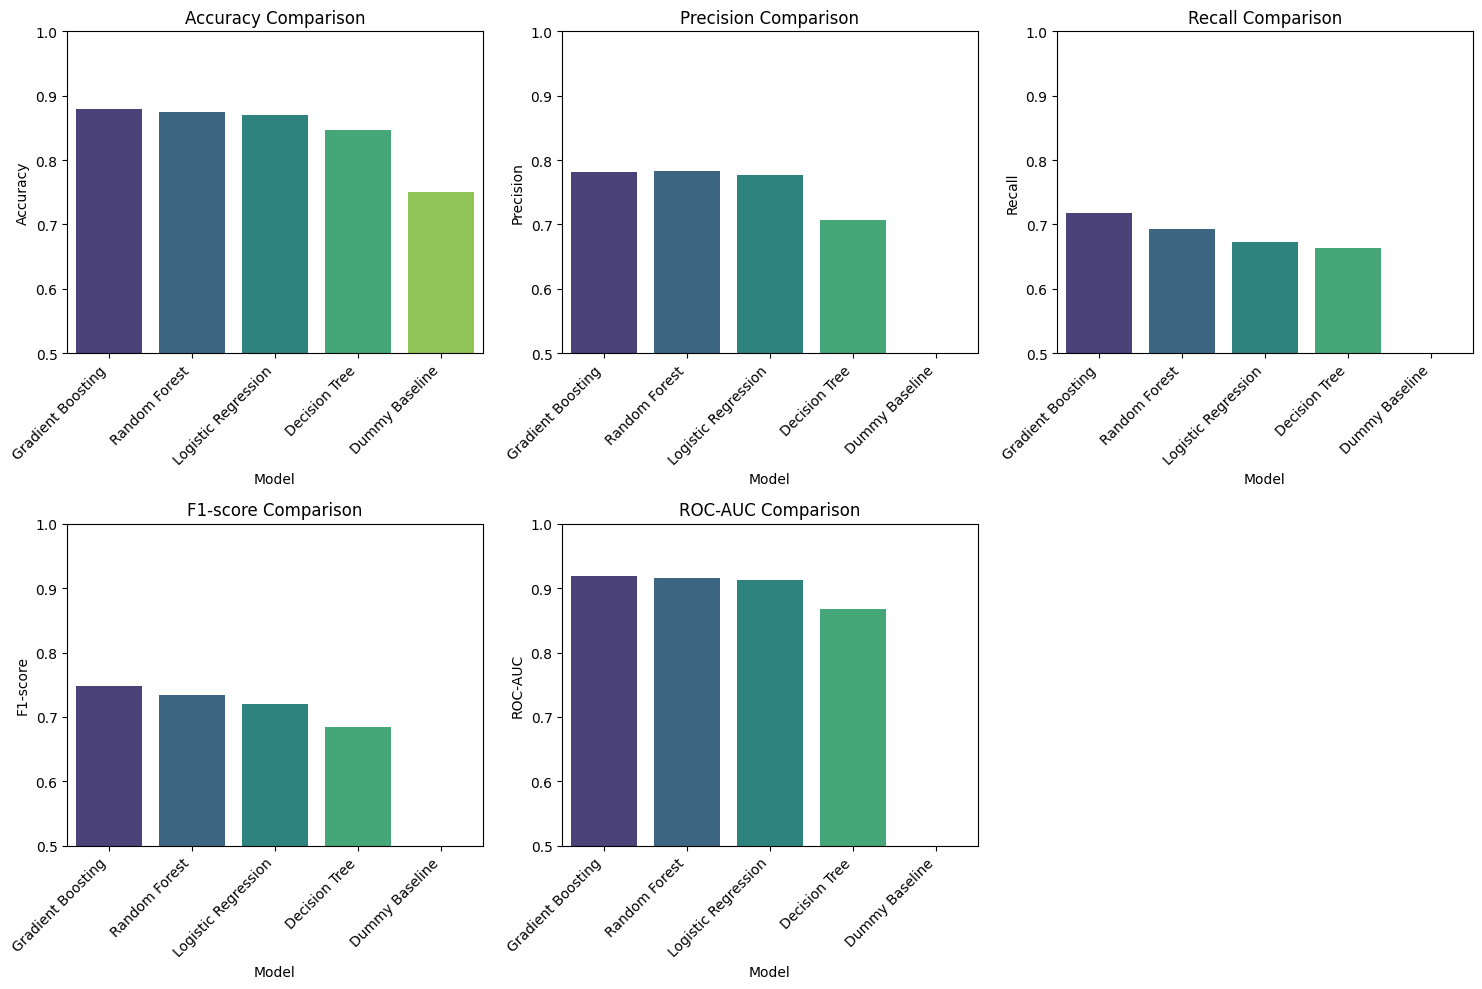

Visual comparison of model performance metrics displayed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'] # Changed 'F1-Score' to 'F1-score' to match results_df

plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i + 1)
    sns.barplot(x=results_df['Model'], y=results_df[metric], hue=results_df['Model'], palette='viridis', legend=False) # Used results_df
    plt.title(f'{metric} Comparison')
    plt.ylabel(metric)
    plt.xlabel('Model')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0.5, 1.0) # Set a common y-limit for better comparison

plt.tight_layout()
plt.show()

print("Visual comparison of model performance metrics displayed.")

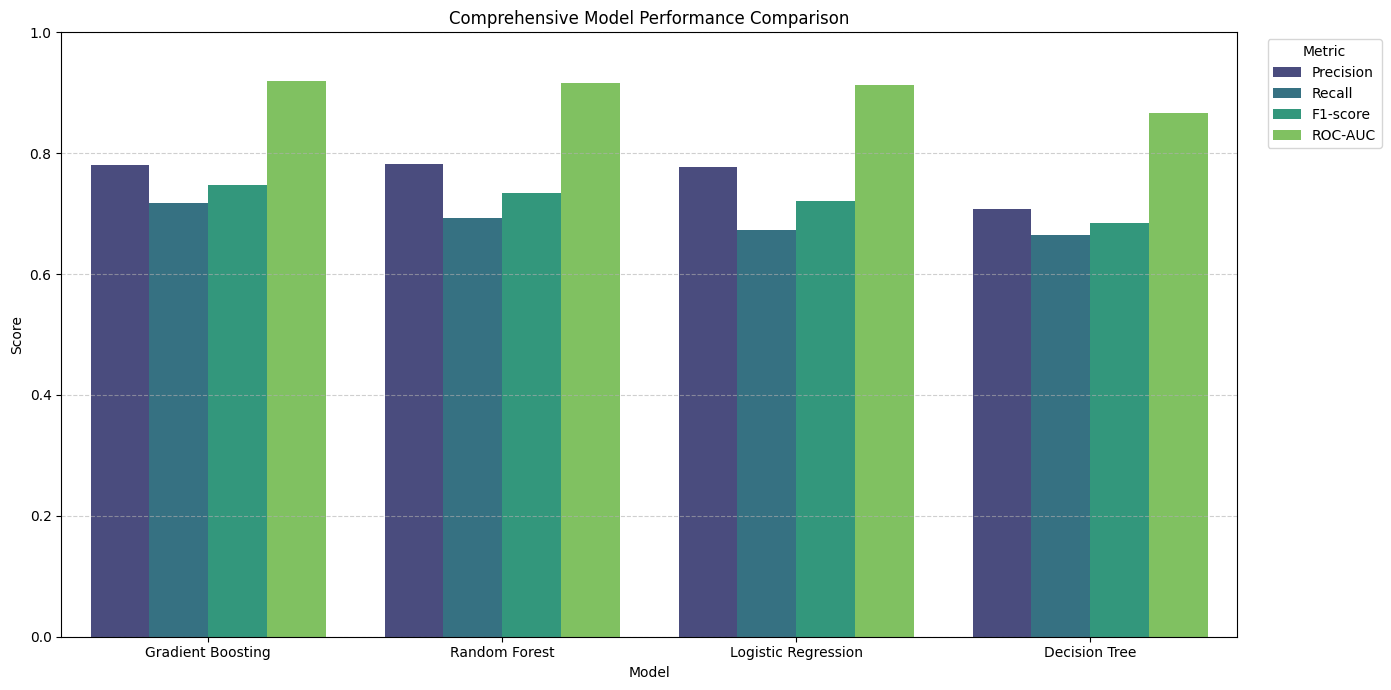

In [ ]:
# Consolidated Visual Performance Comparison for all models
plot_results = results_df[results_df['Model'] != 'Dummy Baseline'].melt(
    id_vars='Model', value_vars=['Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    var_name='Metric', value_name='Score'
)

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_results, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Comprehensive Model Performance Comparison')
plt.ylim(0, 1)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



---



### **Model Findings**

#### Best-performing model based on the chosen evaluation metrics

In [ ]:
print("Model Performance Comparison:\n")
display(results_df)

# Identify the best performing model based on AUC, F1-Score, and Precision
best_auc_model = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_f1_model = results_df.loc[results_df['F1-score'].idxmax(), 'Model']
best_precision_model = results_df.loc[results_df['Precision'].idxmax(), 'Model']

print(f"\nBest Model by AUC: {best_auc_model} (AUC: {results_df.loc[results_df['ROC-AUC'].idxmax(), 'ROC-AUC']:.3f})")
print(f"Best Model by F1-Score: {best_f1_model} (F1-Score: {results_df.loc[results_df['F1-score'].idxmax(), 'F1-score']:.3f})")
print(f"Best Model by Precision: {best_precision_model} (Precision: {results_df.loc[results_df['Precision'].idxmax(), 'Precision']:.3f})")

Model Performance Comparison:



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosting,0.879222,0.781250,0.717213,0.747863,0.919268
1,Random Forest,0.875128,0.782407,0.692623,0.734783,0.915511
2,Logistic Regression,0.870010,0.777251,0.672131,0.720879,0.912319
3,Decision Tree,0.847492,0.707424,0.663934,0.684989,0.867304
4,Dummy Baseline,0.750256,0.000000,0.000000,0.000000,0.500000



Best Model by AUC: Gradient Boosting (AUC: 0.919)
Best Model by F1-Score: Gradient Boosting (F1-Score: 0.748)
Best Model by Precision: Random Forest (Precision: 0.782)




---



## **Strategic Analysis**

Beyond basic classification metrics:
* We use a **Lift Chart** to quantify the commercial value of the model.

    *And*

* A **Correlation Heatmap** to ensure our engineered features provide independent predictive signals.

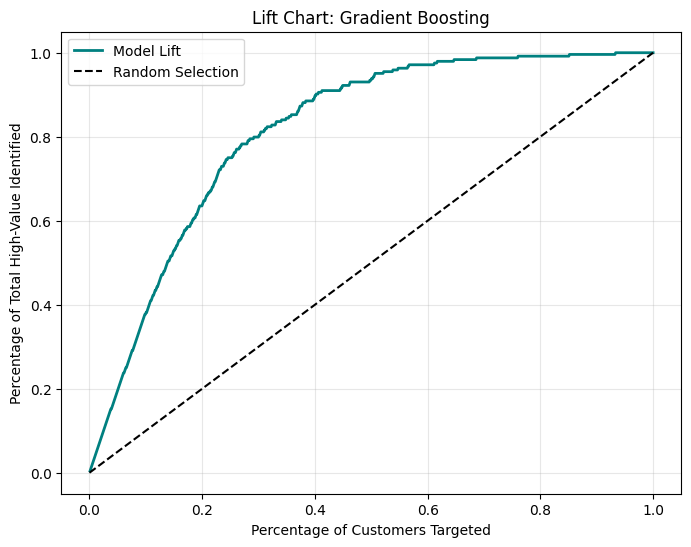

In [ ]:
def plot_lift_chart(y_true, y_probs, model_name):
    # Sort by probability
    data = pd.DataFrame({'true': y_true, 'prob': y_probs}).sort_values('prob', ascending=False)
    data['cumulative_true'] = data['true'].cumsum() / data['true'].sum()
    data['percentile'] = np.arange(1, len(data) + 1) / len(data)

    plt.figure(figsize=(8, 6))
    plt.plot(data['percentile'], data['cumulative_true'], label='Model Lift', color='teal', lw=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Selection')
    plt.title(f'Lift Chart: {model_name}')
    plt.xlabel('Percentage of Customers Targeted')
    plt.ylabel('Percentage of Total High-Value Identified')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Visualize Lift for the winning Gradient Boosting model
best_model_name = (
    results_df[results_df['Model'] != 'Dummy Baseline']
    .sort_values('ROC-AUC', ascending=False)
    .iloc[0]['Model']
)

plot_lift_chart(
    y_test,
    test_probabilities[best_model_name],
    best_model_name
)

**Interpretation:** The Lift Chart shows how much more effective targeting is when using the model compared to random selection. For instance, if the curve hits 0.8 at the 0.3 x-axis mark, it means we can capture 80% of all high-value customers by only targeting the top 30% predicted by the model.

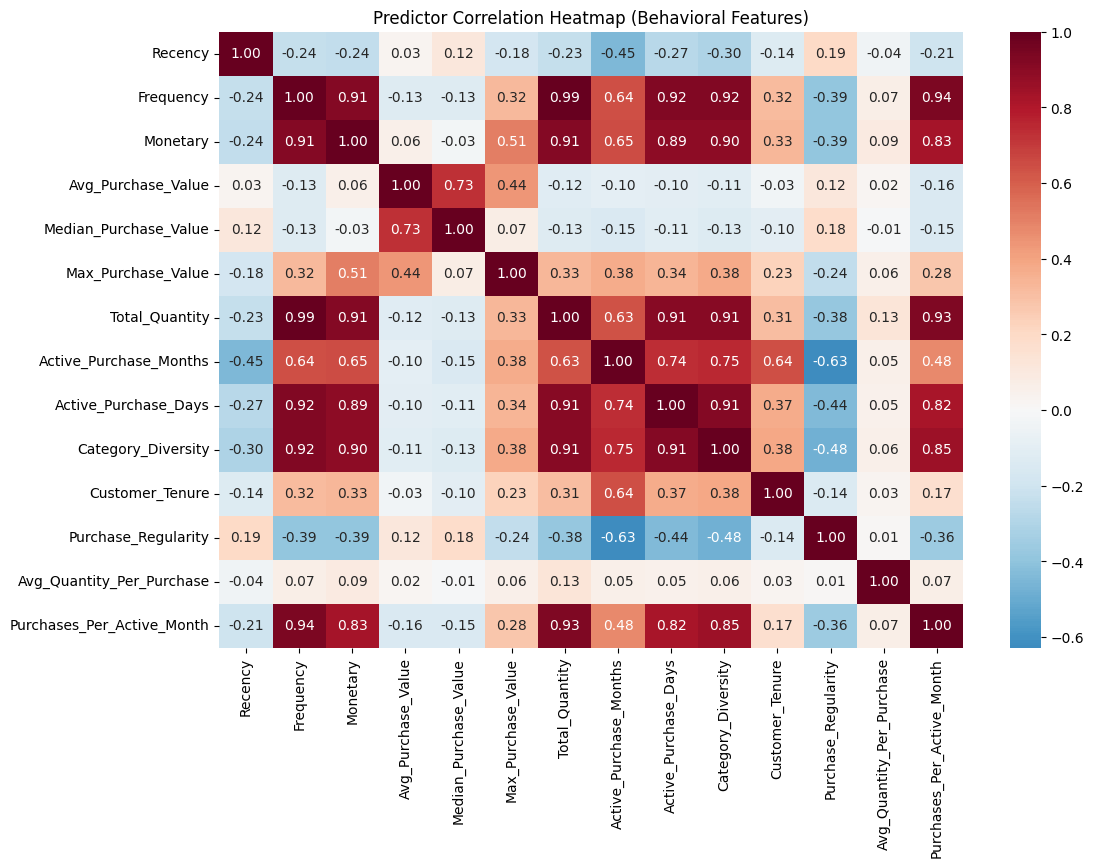

In [ ]:
# Feature Independence Check: Correlation Heatmap of Numeric Predictors
plt.figure(figsize=(12, 8))
sns.heatmap(X_train[numeric_features].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Predictor Correlation Heatmap (Behavioral Features)')
plt.show()



---



## **ROC Curve Comparison**

* ROC curves compare the models across possible probability thresholds.

* A model with stronger ROC-AUC is better at ranking customers who later become high value above customers who do not.

#### **Individual and Consolidated ROC Curve Analysis**

The plots below allow for a closer inspection of each model:
- **Gradient Boosting & Random Forest:** Show a strong 'bow' towards the top-left corner, indicating high sensitivity even at low false-positive rates.
- **Logistic Regression:** Shows a smooth curve, typical for linear probability estimation.
- **Decision Tree:** Exhibits a more 'stepped' appearance, reflecting the discrete nature of probability scores derived from leaf nodes.

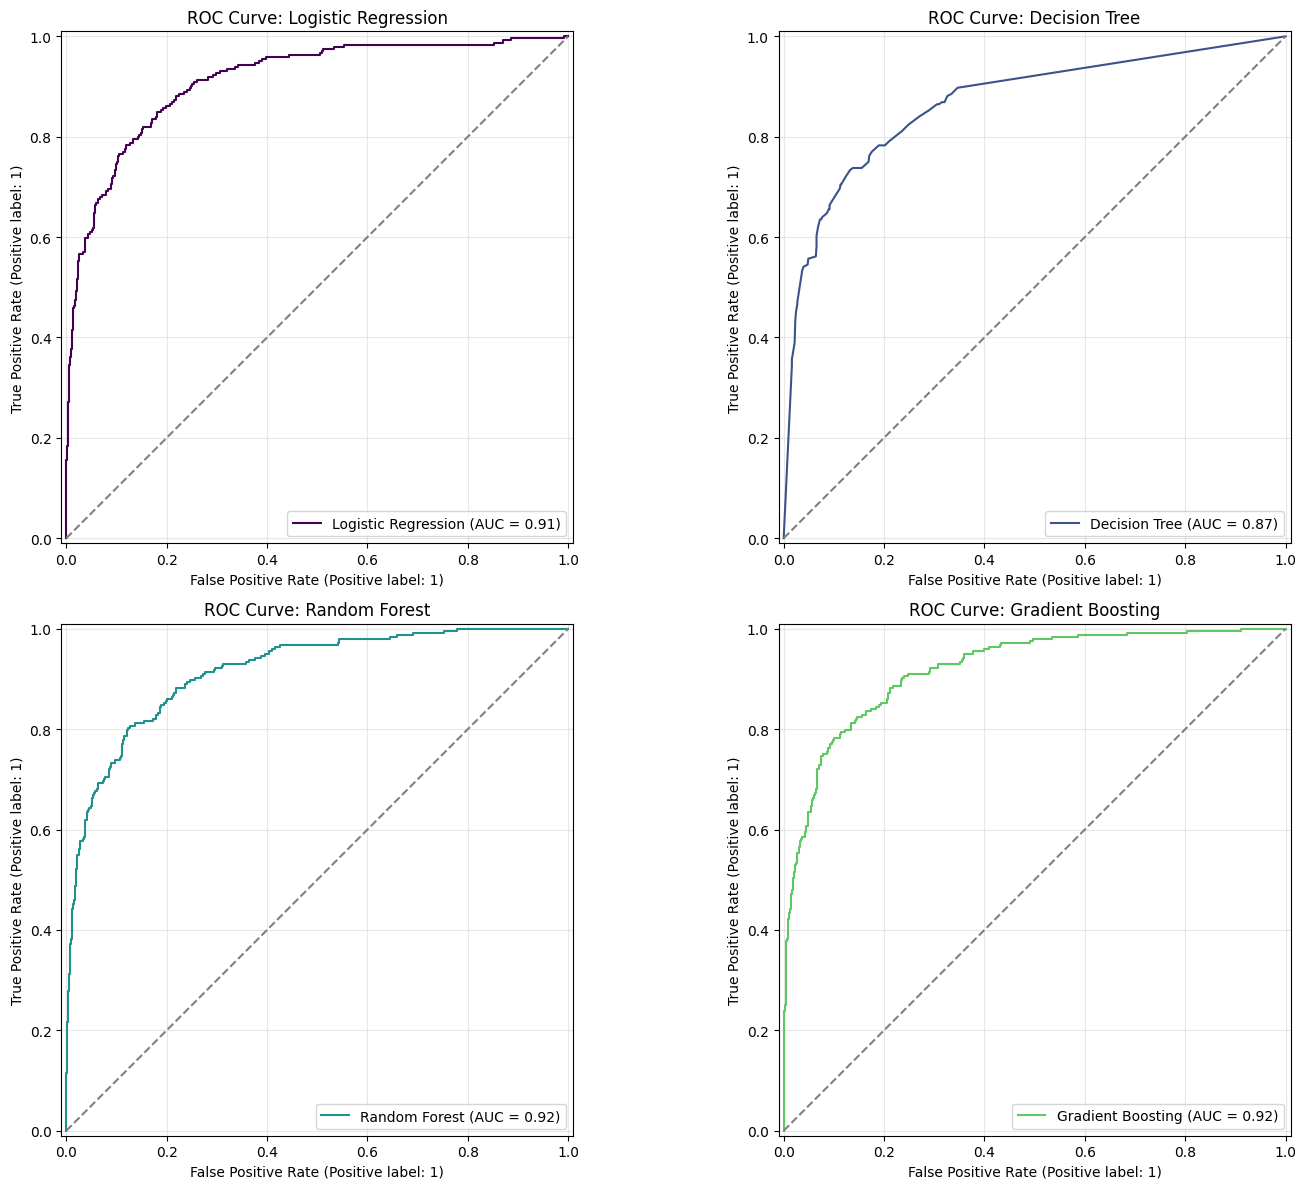

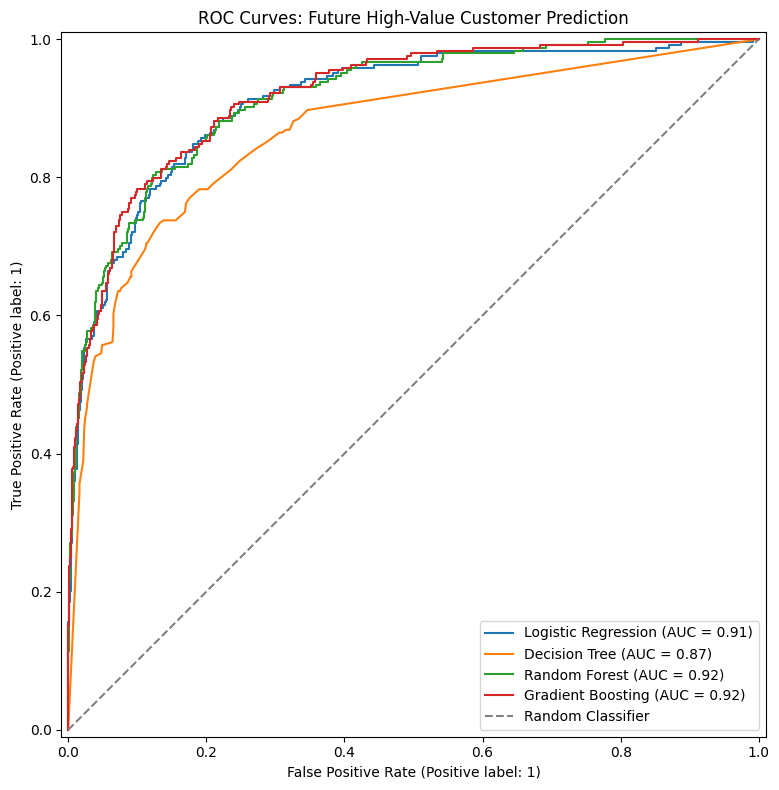

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# List of models to plot (excluding Dummy Baseline for clarity)
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, name in enumerate(model_names):
    RocCurveDisplay.from_predictions(
        y_test,
        test_probabilities[name],
        name=name,
        ax=axes[i],
        color=plt.cm.viridis(i / len(model_names))
    )
    axes[i].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[i].set_title(f'ROC Curve: {name}')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Consolidated ROC Curves
plt.figure(figsize=(10, 8))
ax = plt.gca()
for name in ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']:
    RocCurveDisplay.from_predictions(y_test, test_probabilities[name], name=name, ax=ax)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.title('ROC Curves: Future High-Value Customer Prediction')
plt.legend()
plt.tight_layout()
plt.show()



---



## **Selection of Best Untuned Model**

The initial best model is selected mainly using **ROC-AUC**, supported by **F1-score**, **precision**, **recall**, and **model interpretability**.

In [ ]:
# --- 5. Winning Model Deep Dive ---
eligible_results = results_df[results_df['Model'] != 'Dummy Baseline'].copy()
best_model_name = eligible_results.iloc[0]['Model']
print(f"Best untuned model based on ROC-AUC: {best_model_name}")

print("Detailed Classification Report:\n")
print(classification_report(y_test, test_predictions[best_model_name], target_names=['Not High Value', 'High Value'], zero_division=0))

Best untuned model based on ROC-AUC: Gradient Boosting
Detailed Classification Report:

                precision    recall  f1-score   support

Not High Value       0.91      0.93      0.92       733
    High Value       0.78      0.72      0.75       244

      accuracy                           0.88       977
     macro avg       0.84      0.83      0.83       977
  weighted avg       0.88      0.88      0.88       977





---



## **Confusion Matrix for the Best Untuned Model**

The confusion matrix evaluates the best initial model using the default classification threshold of **0.50**.

*Note: This threshold determines the final class assignment after the model calculates the probability of a customer belonging to the 'High-Value' (Top 25%) category.*

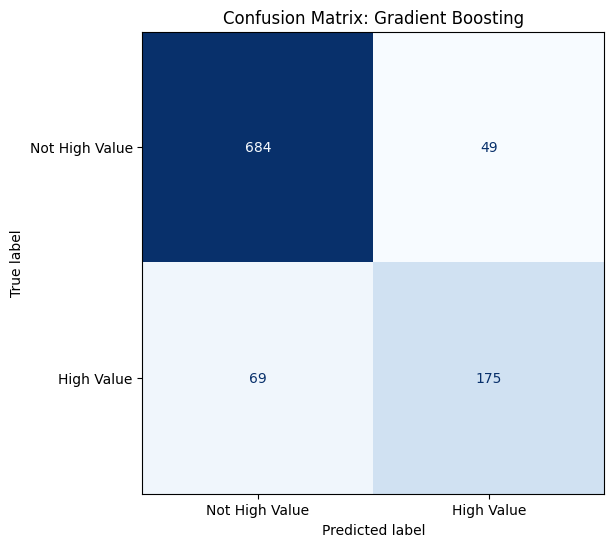

In [ ]:
cm = confusion_matrix(y_test, test_predictions[best_model_name])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not High Value', 'High Value'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', colorbar=False, ax=ax)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.show()



---



## **Feature-Group Comparison**

This analysis tests whether historical purchase behaviour, demographics, or their combination provides the strongest predictive information.

Three feature sets are compared using the same Random Forest model:

1. Behavioural features only
2. Demographic and platform-use features only
3. Combined behavioural and demographic features

In [ ]:
def build_preprocessor(numeric_cols, categorical_cols):
    transformers = []

    if len(numeric_cols) > 0:
        transformers.append(
            ('num', numeric_transformer, numeric_cols)
        )

    if len(categorical_cols) > 0:
        transformers.append(
            ('cat', categorical_transformer, categorical_cols)
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder='drop'
    )

feature_sets = {
    'Behavioural Features Only': (
        numeric_features,
        []
    ),

    'Demographic Features Only': (
        [],
        categorical_features
    ),

    'Combined Features': (
        numeric_features,
        categorical_features
    )
}

feature_set_results = []

for feature_set_name, (
    selected_numeric,
    selected_categorical
) in feature_sets.items():

    selected_cols = (
        selected_numeric +
        selected_categorical
    )

    X_train_subset = X_train[selected_cols]
    X_test_subset = X_test[selected_cols]

    feature_set_pipeline = Pipeline(steps=[
        (
            'preprocessor',
            build_preprocessor(
                selected_numeric,
                selected_categorical
            )
        ),
        (
            'model',
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ])

    feature_set_pipeline.fit(
        X_train_subset,
        y_train
    )

    subset_pred = feature_set_pipeline.predict(
        X_test_subset
    )

    subset_prob = feature_set_pipeline.predict_proba(
        X_test_subset
    )[:, 1]

    feature_set_results.append({
        'Feature Set': feature_set_name,
        'F1-score': f1_score(
            y_test,
            subset_pred,
            zero_division=0
        ),
        'ROC-AUC': roc_auc_score(
            y_test,
            subset_prob
        )
    })

feature_set_results_df = pd.DataFrame(
    feature_set_results
).sort_values(
    by='ROC-AUC',
    ascending=False
)

display(
    feature_set_results_df.style.format({
        'F1-score': '{:.3f}',
        'ROC-AUC': '{:.3f}'
    })
)

,Feature Set,F1-score,ROC-AUC
2,Combined Features,0.735,0.916
0,Behavioural Features Only,0.703,0.901
1,Demographic Features Only,0.515,0.810


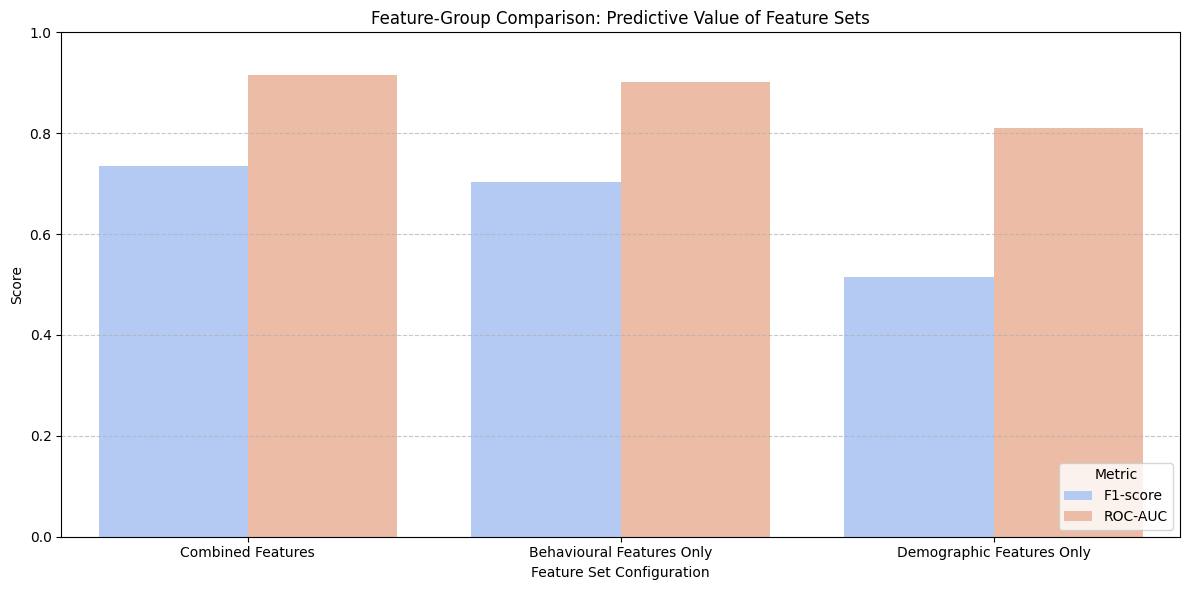

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the feature group comparison data for plotting
plot_feature_comparison = feature_set_results_df.melt(
    id_vars='Feature Set',
    value_vars=['F1-score', 'ROC-AUC'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_feature_comparison, x='Feature Set', y='Score', hue='Metric', palette='coolwarm')

plt.title('Feature-Group Comparison: Predictive Value of Feature Sets')
plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.xlabel('Feature Set Configuration')
plt.legend(title='Metric', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


>  - [x] Behavioural features alone achieved a ROC-AUC of **0.901**.
>   - [x] Demographic features alone achieved a ROC-AUC of **0.810**.
>   - [x] The combined feature set achieved a ROC-AUC of **0.916**.

Therefore, **Combined** features provided the strongest predictive performance. This suggests that **demographics add useful incremental information beyond behaviour**.



---



## **Insights**

#### Actionable insights from the best-performing model (Gradient Boosting) regarding the characteristics of high-value customers.


The Gradient Boosting model does not use regression coefficients. Instead, its tree-based feature importances and the permutation-importance analysis below are used to identify which variables contribute most to predictive performance. These measures show predictive influence, not causal effects or the direction of the relationship.


In [ ]:
import pandas as pd

# Get the trained Gradient Boosting model from the fitted pipelines
gb_model_pipeline = fitted_pipelines['Gradient Boosting']
gb_model = gb_model_pipeline.named_steps['model']

# Get the feature names after preprocessing
# The preprocessor step of the pipeline will have the feature names out after fitting
feature_names = gb_model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get the feature importances from the trained Gradient Boosting model
feature_importances = gb_model.feature_importances_

# Create a DataFrame to easily view feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance value to see most influential features
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Most Influential Features (Feature Importances from Gradient Boosting):")
display(importance_df.head(10))

print("\nBottom 10 Least Influential Features (Feature Importances from Gradient Boosting):")
display(importance_df.tail(10))

Top 10 Most Influential Features (Feature Importances from Gradient Boosting):


,Feature,Importance
2,num__Monetary,0.439425
9,num__Category_Diversity,0.257215
13,num__Purchases_Per_Active_Month,0.095575
83,cat__Q-amazon-use-how-oft_Less than 5 times pe...,0.073885
0,num__Recency,0.029944
84,cat__Q-amazon-use-how-oft_More than 10 times p...,0.020006
4,num__Median_Purchase_Value,0.012058
3,num__Avg_Purchase_Value,0.010664
12,num__Avg_Quantity_Per_Purchase,0.010388
11,num__Purchase_Regularity,0.009697



Bottom 10 Least Influential Features (Feature Importances from Gradient Boosting):


,Feature,Importance
61,cat__Q-demos-state_New Hampshire,0.0
64,cat__Q-demos-state_New York,0.0
67,cat__Q-demos-state_Ohio,0.0
75,cat__Q-demos-state_Texas,0.0
70,cat__Q-demos-state_Pennsylvania,0.0
73,cat__Q-demos-state_South Dakota,0.0
80,cat__Q-demos-state_West Virginia,0.0
79,cat__Q-demos-state_Washington,0.0
82,cat__Q-demos-state_Wyoming,0.0
81,cat__Q-demos-state_Wisconsin,0.0


#### ***Interpretation of the Original Gradient Boosting Feature Importances***

The original tree-based feature importances indicate that historical `Monetary`, `Category_Diversity`, `Purchases_Per_Active_Month`, and `Recency` were important predictors in the baseline Gradient Boosting model. Because standard feature importance can be affected by correlated variables, the tuned-model permutation-importance analysis below provides the main business interpretation.

The permutation analysis measures the decrease in test ROC-AUC after shuffling each original variable. The largest positive decreases identify the most useful predictive signals, but they do not establish causality or whether increasing a variable raises the probability of high future value.




---



### **Marketing Recommendations**

Based on the actionable insights derived from the **Gradient Boosting model** (ROC-AUC of 0.919), Amazon can implement the following marketing strategies to efficiently allocate resources and maximize customer lifetime value:

#### **1. Prioritize Customers with High Historical Monetary Value**
*   **Insight:** `num__Monetary` is the strongest predictor (importance of 0.439).
*   **Strategy:** Segment customers by historical spend. Offer exclusive discounts and tiered loyalty benefits to the top 25% to ensure retention.

#### **2. Encourage Category Exploration and Diversification**
*   **Insight:** `num__Category_Diversity` is the second most important feature (importance of 0.257).
*   **Strategy:** Implement cross-selling campaigns and personalized recommendations that introduce customers to categories they haven't yet explored.

#### **3. Boost Purchasing Frequency within Active Periods**
*   **Insight:** `num__Purchases_Per_Active_Month` (importance of 0.096) indicates intensity matters.
*   **Strategy:** Send timely promotions and behavioral triggers during a customer's observed active buying cycles to increase transaction volume.

#### **4. Re-engage Infrequent Users and Reinforce Recency**
*   **Insight:** Low usage frequency and high `Recency` are strong differentiators for non-high-value status.
*   **Strategy:** Launch win-back campaigns and re-engagement offers specifically for customers who have not purchased recently or use the platform less than 5 times per month.



---



### **Current Progress**

- **Target Achieved:** Successfully defined and predicted high-value customers (Top 25% spenders) with a high degree of accuracy (**ROC-AUC ~0.92**).
- **Key Finding:** Behavioral data (Monetary and Diversity) is the strongest predictor, while demographics provide a meaningful incremental boost to model robustness.
- **Model Selection:** **Gradient Boosting** outperformed linear and simpler tree models, effectively capturing the non-linear nature of customer value and purchase patterns.

## **Model Optimization and Business Interpretation**

### **Step 1: Model Selection for Tuning**

Based on the evaluation results, the strongest-performing model was selected for further optimization. Model selection considered ROC-AUC, F1-score, precision, recall and overall generalization performance rather than accuracy alone. Gradient Boosting was selected because it achieved the strongest ROC-AUC and F1-score among the non-baseline models on the held-out comparison set, while retaining a suitable level of predictive performance for ranking high-value customers.


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance

# Tune only the selected model using the training data and cross-validation.
tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    'model__n_estimators': [100, 150, 250],
    'model__learning_rate': [0.03, 0.05, 0.10],
    'model__max_depth': [2, 3],
    'model__min_samples_leaf': [5, 10]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv_strategy,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

grid_search.fit(X_train, y_train)
tuned_pipeline = grid_search.best_estimator_

print('Best hyperparameters:')
print(grid_search.best_params_)
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.3f}")


Best hyperparameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_samples_leaf': 10, 'model__n_estimators': 100}
Best cross-validated ROC-AUC: 0.924


### **Step 2: Baseline versus Tuned Model**

The baseline Gradient Boosting model and the tuned model are compared on the same untouched test set. Hyperparameters were selected using cross-validation on the training set only; the test set is used here for final generalization assessment.


In [ ]:
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

baseline_gb = fitted_pipelines['Gradient Boosting']
baseline_pred = test_predictions['Gradient Boosting']
baseline_prob = test_probabilities['Gradient Boosting']

tuned_pred = tuned_pipeline.predict(X_test)
tuned_prob = tuned_pipeline.predict_proba(X_test)[:, 1]

comparison_df = pd.DataFrame([
    {'Model': 'Gradient Boosting - Baseline', **calculate_metrics(y_test, baseline_pred, baseline_prob)},
    {'Model': 'Gradient Boosting - Tuned', **calculate_metrics(y_test, tuned_pred, tuned_prob)}
]).set_index('Model')

print('Baseline versus tuned model performance on the untouched test set:')
display(comparison_df.style.format('{:.3f}'))

comparison_delta = (comparison_df.loc['Gradient Boosting - Tuned'] - comparison_df.loc['Gradient Boosting - Baseline']).to_frame('Tuned minus Baseline')
print('Change after tuning:')
display(comparison_delta.style.format('{:+.3f}'))


Baseline versus tuned model performance on the untouched test set:


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Gradient Boosting - Baseline,0.879,0.781,0.717,0.748,0.919
Gradient Boosting - Tuned,0.874,0.764,0.717,0.740,0.920


Change after tuning:


,Tuned minus Baseline
Accuracy,-0.005
Precision,-0.017
Recall,+0.000
F1-score,-0.008
ROC-AUC,+0.001


### **Step 3: Final Evaluation of the Tuned Model**

The tuned model is evaluated once on the untouched test set. The confusion matrix shows classification errors at the default 0.50 threshold, while the ROC curve shows ranking performance across possible thresholds.


Final tuned-model metrics:


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Gradient Boosting - Tuned,0.874,0.764,0.717,0.740,0.920


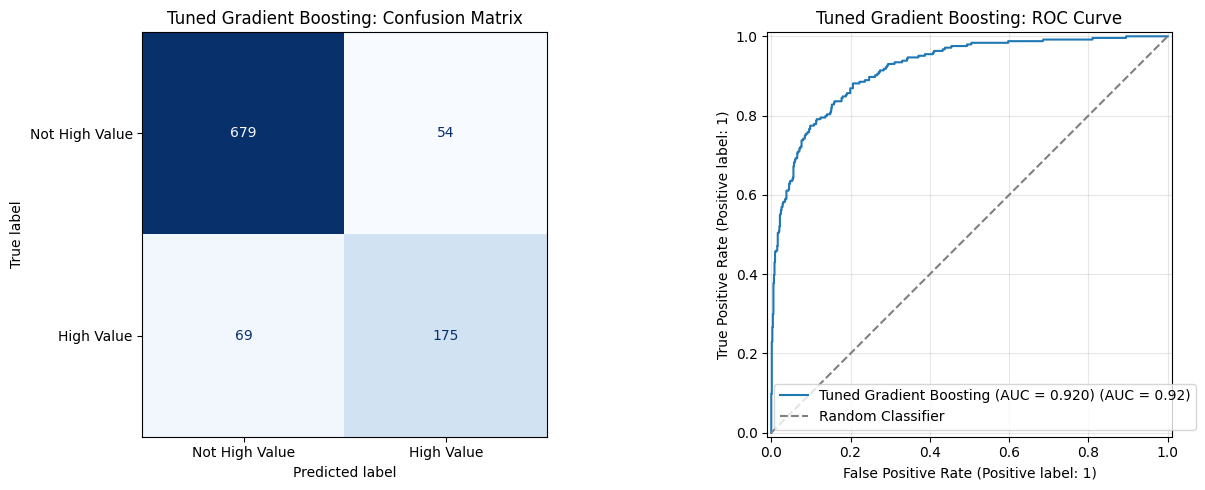

                precision    recall  f1-score   support

Not High Value       0.91      0.93      0.92       733
    High Value       0.76      0.72      0.74       244

      accuracy                           0.87       977
     macro avg       0.84      0.82      0.83       977
  weighted avg       0.87      0.87      0.87       977



In [ ]:
final_metrics = calculate_metrics(y_test, tuned_pred, tuned_prob)
print('Final tuned-model metrics:')
display(pd.DataFrame([final_metrics], index=['Gradient Boosting - Tuned']).style.format('{:.3f}'))

final_cm = confusion_matrix(y_test, tuned_pred)
final_disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=['Not High Value', 'High Value']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
final_disp.plot(cmap='Blues', colorbar=False, ax=axes[0])
axes[0].set_title('Tuned Gradient Boosting: Confusion Matrix')

RocCurveDisplay.from_predictions(
    y_test,
    tuned_prob,
    name=f'Tuned Gradient Boosting (AUC = {final_metrics["ROC-AUC"]:.3f})',
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
axes[1].set_title('Tuned Gradient Boosting: ROC Curve')
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

print(classification_report(
    y_test,
    tuned_pred,
    target_names=['Not High Value', 'High Value'],
    zero_division=0
))


### **Step 4: Model Interpretation and Business Meaning**

Permutation importance measures how much the tuned model's test ROC-AUC decreases when one original input variable is randomly shuffled. Larger positive values indicate variables that are more influential for prediction. This interpretation is descriptive and does not change the already-finalized test evaluation.


Top variables influencing the tuned model predictions:


,Feature,Mean ROC-AUC decrease,Std. deviation
2,Monetary,0.0692,0.0082
19,Q-amazon-use-how-oft,0.0322,0.0044
13,Purchases_Per_Active_Month,0.0177,0.0052
0,Recency,0.0139,0.0025
9,Category_Diversity,0.0039,0.0016
3,Avg_Purchase_Value,0.0022,0.0013
11,Purchase_Regularity,0.0011,0.0009
15,Q-demos-income,0.0010,0.0005
7,Active_Purchase_Months,0.0004,0.0007
18,Q-demos-state,0.0004,0.0005


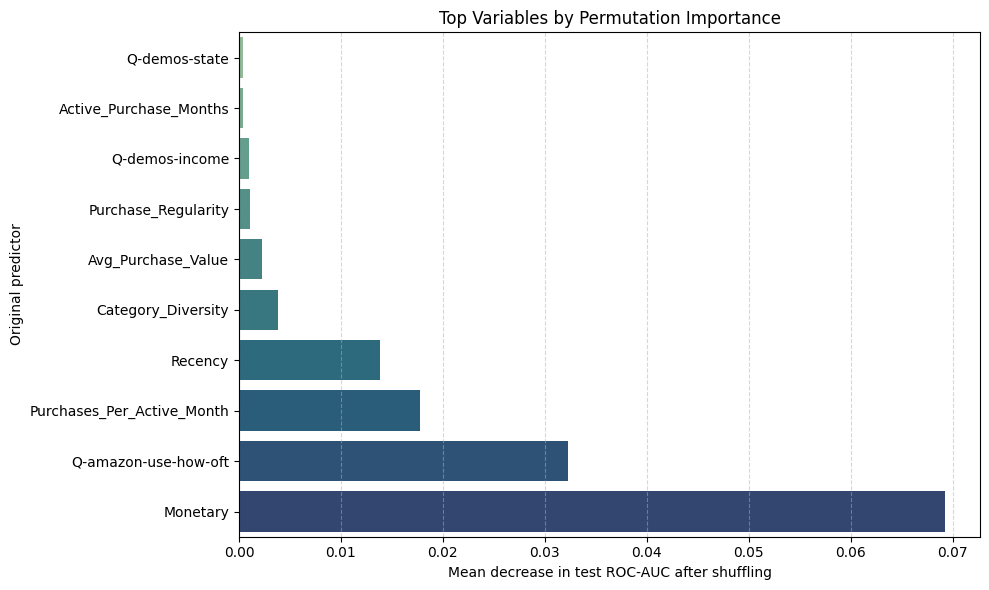

Business interpretation: variables with the largest positive ROC-AUC decrease are the most useful signals for identifying future high-value customers. These variables should guide customer segmentation, retention, and cross-selling; they indicate predictive association, not causation.


In [ ]:
permutation_result = permutation_importance(
    tuned_pipeline,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean ROC-AUC decrease': permutation_result.importances_mean,
    'Std. deviation': permutation_result.importances_std
}).sort_values('Mean ROC-AUC decrease', ascending=False)

print('Top variables influencing the tuned model predictions:')
display(permutation_importance_df.head(10).style.format({
    'Mean ROC-AUC decrease': '{:.4f}',
    'Std. deviation': '{:.4f}'
}))

plt.figure(figsize=(10, 6))
top_importance = permutation_importance_df.head(10).sort_values('Mean ROC-AUC decrease')
sns.barplot(
    data=top_importance,
    x='Mean ROC-AUC decrease',
    y='Feature',
    hue='Feature',
    palette='crest',
    legend=False
)
plt.title('Top Variables by Permutation Importance')
plt.xlabel('Mean decrease in test ROC-AUC after shuffling')
plt.ylabel('Original predictor')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(
    'Business interpretation: variables with the largest positive ROC-AUC decrease '
    'are the most useful signals for identifying future high-value customers. '
    'These variables should guide customer segmentation, retention, and cross-selling; '
    'they indicate predictive association, not causation.'
)


### **Step 5: Probability Decile and Lift Analysis**

To answer whether the highest predicted-probability customers contain substantially more future high-value customers than a random selection, the untouched test set is divided into ten probability deciles. Decile 10 contains the customers with the highest predicted probabilities. Lift is calculated relative to the overall high-value rate in the test set.


Probability decile performance on the untouched test set:


,Decile,Customers,High_Value_Customers,High_Value_Rate,Lift,Cumulative_High_Value_Capture
9,10,98,93,94.90%,3.80x,38.11%
8,9,98,63,64.29%,2.57x,63.93%
7,8,97,38,39.18%,1.57x,79.51%
6,7,98,23,23.47%,0.94x,88.93%
5,6,98,14,14.29%,0.57x,94.67%
4,5,97,7,7.22%,0.29x,97.54%
3,4,98,3,3.06%,0.12x,98.77%
2,3,97,1,1.03%,0.04x,99.18%
1,2,98,1,1.02%,0.04x,99.59%
0,1,98,1,1.02%,0.04x,100.00%


Top-decile high-value rate: 94.90%; overall test-set rate: 24.97%; lift: 3.80x; cumulative capture: 38.11%.
Top-decile customer profile compared with the full test set:


,Top Decile Mean,Overall Test Mean,Difference
Monetary,15493.56,4548.37,10945.19
Recency,2.59,45.70,-43.10
Category_Diversity,227.19,81.10,146.10
Purchases_Per_Active_Month,18.62,7.07,11.56
Frequency,658.31,193.20,465.11
Avg_Purchase_Value,24.44,26.42,-1.98


Numeric customer profile for every probability decile:


...

,Decile,Q-demos-age,Q-demos-income,Q-demos-gender,Q-demos-education,Q-demos-state,Q-amazon-use-how-oft
9,10,35 - 44 years (28.6%),"$100,000 - $149,999 (34.7%)",Female (56.1%),Bachelor's degree (44.9%),California (10.2%),More than 10 times per month (50.0%)
8,9,25 - 34 years (31.6%),"$100,000 - $149,999 (27.6%)",Male (53.1%),Bachelor's degree (40.8%),California (14.3%),5 - 10 times per month (62.2%)
7,8,25 - 34 years (39.2%),"$50,000 - $74,999 (27.8%)",Female (51.5%),High school diploma or GED (41.2%),Texas (12.4%),5 - 10 times per month (55.7%)
6,7,25 - 34 years (40.8%),"$25,000 - $49,999 (21.4%)",Female (50.0%),Bachelor's degree (44.9%),California (9.2%),Less than 5 times per month (56.1%)
5,6,25 - 34 years (37.8%),"$25,000 - $49,999 (23.5%)",Female (50.0%),Bachelor's degree (43.9%),New York (8.2%),Less than 5 times per month (68.4%)
4,5,25 - 34 years (30.9%),"$50,000 - $74,999 (29.9%)",Female (54.6%),Bachelor's degree (47.4%),Florida (8.2%),Less than 5 times per month (73.2%)
3,4,25 - 34 years (40.8%),"$25,000 - $49,999 (29.6%)",Female (48.0%),Bachelor's degree (40.8%),California (12.2%),Less than 5 times per month (79.6%)
2,3,25 - 34 years (44.3%),"$25,000 - $49,999 (24.7%)",Male (49.5%),Bachelor's degree (48.5%),California (9.3%),Less than 5 times per month (99.0%)
1,2,25 - 34 years (32.7%),"$25,000 - $49,999 (31.6%)",Female (49.0%),Bachelor's degree (49.0%),California (9.2%),Less than 5 times per month (96.9%)
0,1,25 - 34 years (39.8%),"$50,000 - $74,999 (26.5%)",Female (54.1%),Bachelor's degree (45.9%),New York (9.2%),Less than 5 times per month (100.0%)


Focused readout for the most actionable deciles (top 3 and bottom 3):


,Customers,High_Value_Rate,Mean_Monetary,Median_Monetary,Mean_Recency,Mean_Frequency,Mean_Category_Diversity,Mean_Purchases_Per_Active_Month,Mean_Avg_Purchase_Value,Segment_Readout
Decile,,,,,,,,,,
10,98,94.90%,15493.56,13901.65,2.59,658.31,227.19,18.62,24.44,Highest-priority segment for retention and premium targeting
9,98,64.29%,8805.77,8358.93,4.40,345.92,146.53,10.62,27.48,Very strong prospect segment with above-average future value concentration
8,97,39.18%,6265.00,5995.67,14.88,274.68,112.28,9.43,25.53,"Still commercially attractive, but less concentrated than the top two deciles"
3,97,1.03%,1187.96,1037.98,42.94,48.16,28.54,3.29,28.62,Below-average segment with weaker high-value concentration
2,98,1.02%,750.80,731.91,93.42,35.17,22.19,2.71,23.95,Low-priority segment with limited high-value density
1,98,1.02%,428.99,307.50,204.65,21.59,13.85,2.26,29.51,Lowest-priority segment; customers are least likely to become high value


Example Survey ResponseIDs in the highest predicted-probability decile:


,Survey ResponseID,Predicted_Probability
0,R_2VwjXhJ5OznStEi,0.985
1,R_3mmCGclG1nJL4uv,0.984
2,R_3oO3DoeTgXHrEzx,0.984
3,R_10CAlrx7dbJty9R,0.983
4,R_1C4nKyrv0w2thJn,0.982
5,R_32Mm71oAJq2K9XK,0.982
6,R_1od3pz9nFmDAkiu,0.980
7,R_e8KTElZZLWryLWp,0.979
8,R_2WAagX64hf1kdMI,0.978
9,R_2XoI6KbLJRGFz5X,0.978


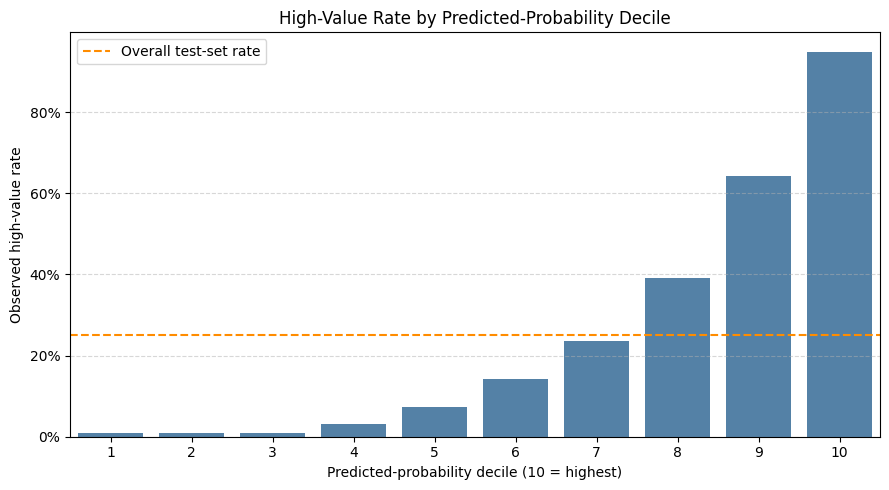

In [ ]:
decile_data = X_test.copy()
decile_data['Survey ResponseID'] = id_test.to_numpy()
decile_data['Actual_HighValue'] = y_test.to_numpy()
decile_data['Predicted_Probability'] = tuned_prob

decile_data = decile_data.sort_values('Predicted_Probability', ascending=False).reset_index(drop=True)

# Decile 10 is the top 10% of customers by predicted probability.
decile_data['Decile'] = pd.qcut(
    decile_data.index,
    q=10,
    labels=list(range(10, 0, -1))
).astype(int)

overall_high_value_rate = decile_data['Actual_HighValue'].mean()
decile_table = decile_data.groupby('Decile', as_index=False, observed=False).agg(
    Customers=('Survey ResponseID', 'count'),
    High_Value_Customers=('Actual_HighValue', 'sum'),
    High_Value_Rate=('Actual_HighValue', 'mean')
).sort_values('Decile', ascending=False)

decile_table['Lift'] = decile_table['High_Value_Rate'] / overall_high_value_rate
decile_table['Cumulative_High_Value_Capture'] = (
    decile_table['High_Value_Customers'].cumsum() /
    decile_table['High_Value_Customers'].sum()
)

print('Probability decile performance on the untouched test set:')
display(decile_table.style.format({
    'High_Value_Rate': '{:.2%}',
    'Lift': '{:.2f}x',
    'Cumulative_High_Value_Capture': '{:.2%}'
}))

top_decile = decile_data[decile_data['Decile'] == 10].copy()
print(
    f"Top-decile high-value rate: {top_decile['Actual_HighValue'].mean():.2%}; "
    f"overall test-set rate: {overall_high_value_rate:.2%}; "
    f"lift: {(top_decile['Actual_HighValue'].mean() / overall_high_value_rate):.2f}x; "
    f"cumulative capture: {decile_table.iloc[0]['Cumulative_High_Value_Capture']:.2%}."
)

profile_numeric_cols = [
    'Monetary',
    'Recency',
    'Category_Diversity',
    'Purchases_Per_Active_Month',
    'Frequency',
    'Avg_Purchase_Value'
]

top_decile_profile = pd.DataFrame({
    'Top Decile Mean': top_decile[profile_numeric_cols].mean(),
    'Overall Test Mean': decile_data[profile_numeric_cols].mean(),
    'Difference': top_decile[profile_numeric_cols].mean() - decile_data[profile_numeric_cols].mean()
})

print('Top-decile customer profile compared with the full test set:')
display(top_decile_profile.style.format('{:.2f}'))

decile_numeric_profile = decile_data.groupby('Decile', observed=False).agg(
    Customers=('Survey ResponseID', 'count'),
    High_Value_Rate=('Actual_HighValue', 'mean'),
    Mean_Monetary=('Monetary', 'mean'),
    Median_Monetary=('Monetary', 'median'),
    Mean_Recency=('Recency', 'mean'),
    Mean_Frequency=('Frequency', 'mean'),
    Mean_Category_Diversity=('Category_Diversity', 'mean'),
    Mean_Purchases_Per_Active_Month=('Purchases_Per_Active_Month', 'mean'),
    Mean_Avg_Purchase_Value=('Avg_Purchase_Value', 'mean')
).sort_index(ascending=False)

print('Numeric customer profile for every probability decile:')
display(decile_numeric_profile.style.format({
    'High_Value_Rate': '{:.2%}',
    'Mean_Monetary': '{:.2f}',
    'Median_Monetary': '{:.2f}',
    'Mean_Recency': '{:.2f}',
    'Mean_Frequency': '{:.2f}',
    'Mean_Category_Diversity': '{:.2f}',
    'Mean_Purchases_Per_Active_Month': '{:.2f}',
    'Mean_Avg_Purchase_Value': '{:.2f}'
}))

profile_categorical_cols = [
    'Q-demos-age',
    'Q-demos-income',
    'Q-demos-gender',
    'Q-demos-education',
    'Q-demos-state',
    'Q-amazon-use-how-oft'
]

top_decile_categorical_profile = pd.concat(
    {
        col: top_decile[col].value_counts(normalize=True).head(3)
        for col in profile_categorical_cols
    },
    axis=1
).fillna(0)

print('Most common categories within the top predicted-probability decile:')
display(top_decile_categorical_profile.style.format('{:.2%}'))

decile_categorical_profile_rows = []
for decile_label, decile_subset in decile_data.groupby('Decile', observed=False):
    row = {'Decile': decile_label}
    for col in profile_categorical_cols:
        top_category = decile_subset[col].value_counts(normalize=True).head(1)
        if len(top_category) == 0:
            row[col] = 'N/A'
        else:
            row[col] = f"{top_category.index[0]} ({top_category.iloc[0]:.1%})"
    decile_categorical_profile_rows.append(row)

decile_categorical_profile = pd.DataFrame(decile_categorical_profile_rows).sort_values('Decile', ascending=False)

print('Most common categorical groups in every probability decile:')
display(decile_categorical_profile)

focus_deciles = [10, 9, 8, 3, 2, 1]
focus_decile_summary = decile_numeric_profile.loc[focus_deciles].copy()
focus_decile_summary['Segment_Readout'] = [
    'Highest-priority segment for retention and premium targeting',
    'Very strong prospect segment with above-average future value concentration',
    'Still commercially attractive, but less concentrated than the top two deciles',
    'Below-average segment with weaker high-value concentration',
    'Low-priority segment with limited high-value density',
    'Lowest-priority segment; customers are least likely to become high value'
]

print('Focused readout for the most actionable deciles (top 3 and bottom 3):')
display(focus_decile_summary.style.format({
    'High_Value_Rate': '{:.2%}',
    'Mean_Monetary': '{:.2f}',
    'Median_Monetary': '{:.2f}',
    'Mean_Recency': '{:.2f}',
    'Mean_Frequency': '{:.2f}',
    'Mean_Category_Diversity': '{:.2f}',
    'Mean_Purchases_Per_Active_Month': '{:.2f}',
    'Mean_Avg_Purchase_Value': '{:.2f}'
}))

print('Example Survey ResponseIDs in the highest predicted-probability decile:')
display(top_decile[['Survey ResponseID', 'Predicted_Probability']].head(10).style.format({
    'Predicted_Probability': '{:.3f}'
}))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=decile_table.sort_values('Decile'),
    x='Decile',
    y='High_Value_Rate',
    color='steelblue'
)
plt.axhline(overall_high_value_rate, color='darkorange', linestyle='--', label='Overall test-set rate')
plt.title('High-Value Rate by Predicted-Probability Decile')
plt.xlabel('Predicted-probability decile (10 = highest)')
plt.ylabel('Observed high-value rate')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
